In [6]:
import numpy as np
import pandas as pd
import torch
from pathlib import Path

from sklearn.metrics import accuracy_score, f1_score, brier_score_loss
from agents.ffnn_agent2 import FFNNAgent

# Your Dataset class
from dataset import Dataset   # if Dataset is in dataset.py
# (Otherwise it's already in-notebook)

# You already have these in your environment/notebook from your project:
# - FFNNAgent
# - build_ffnn_config
# - predict_proba_binary
# - safe_auc
def make_ffnn_config(input_size: int, seed: int):
    return {
        "input_size": input_size,
        "hidden_sizes": [32, 16],
        "output_size": 2,
        "learning_rate": 1e-3,
        "batch_size": 64,
        "epochs": 10,
        "type": "classification",
        "classes": [0, 1],
        "device": torch.device(device),
        "seed": seed,
    }
from sklearn.metrics import roc_auc_score
import numpy as np

def safe_auc(y_true, y_prob):
    """
    Returns ROC-AUC if both classes are present in y_true.
    If a split ends up single-class (can happen with biasing), return NaN.
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, y_prob))

def predict_proba_binary(agent, X_tensor):
    """
    Returns P(y=1) for a binary classifier.
    Assumes FFNNAgent outputs logits of shape [N, 2].
    """
    agent.model.eval()
    with torch.no_grad():
        logits = agent.model(X_tensor)
        probs = torch.softmax(logits, dim=1)
        return probs[:, 1].detach().cpu().numpy()

# ----------------------------
# CONFIG
# ----------------------------
RUN_A = "SPECcredit_EP6000_PCA10_REWlocal_gauss_minID1_majID0_TRJ2000_REAL3000_BIAS0.35_GG202601121133_62ea94db"
RUN_B = "SPECcredit_protected_EP6000_PCA10_REWlocal_gauss_minID1_majID0_TRJ2000_REAL3000_BIAS0.35_GG202601121234_9564f34d"

TRAIN_ROOT = Path("training_runs")

SEEDS = [42, 123]  # edit if needed
DATASET_NAME = "credit_card"
MULTICLASS = False
MINORITY_ID = 1
MAJORITY_ID = 0
THIRD_ID = None

BIAS_PCT = 0.35
PCA_COMPONENTS = 10
VAL_FRAC = 0.20
TEST_FRAC = 0.20
TRAIN_SIZE = None

THRESHOLD = 0.5
PROTECTED_COLS = ["SEX", "AGE"]

device = "cuda" if torch.cuda.is_available() else "cpu"

def alpha_ckpt(run_folder: str, seed: int) -> Path:
    return TRAIN_ROOT / run_folder / f"seed_{seed}" / "alpha_state_dict.pt"

def beta_ckpt(run_folder: str, seed: int) -> Path:
    return TRAIN_ROOT / run_folder / f"seed_{seed}" / "best_beta_state_dict.pt"

# ----------------------------
# Fairness metric helpers
# ----------------------------
def _safe_div(a, b):
    return float(a) / float(b) if b != 0 else np.nan

def _rates(y_true, y_hat):
    y_true = np.asarray(y_true).astype(int)
    y_hat  = np.asarray(y_hat).astype(int)

    tp = int(((y_true == 1) & (y_hat == 1)).sum())
    tn = int(((y_true == 0) & (y_hat == 0)).sum())
    fp = int(((y_true == 0) & (y_hat == 1)).sum())
    fn = int(((y_true == 1) & (y_hat == 0)).sum())

    ppr = _safe_div((y_hat == 1).sum(), len(y_hat))  # predicted positive rate
    tpr = _safe_div(tp, tp + fn)                     # TPR / recall for class 1
    fpr = _safe_div(fp, fp + tn)                     # FPR
    ppv = _safe_div(tp, tp + fp)                     # PPV / precision for class 1
    return ppr, tpr, fpr, ppv

def fairness_diffs(y_true, y_hat, mask_a1):
    mask_a1 = np.asarray(mask_a1).astype(bool)
    y_true = np.asarray(y_true).astype(int)
    y_hat  = np.asarray(y_hat).astype(int)

    ppr0, tpr0, fpr0, ppv0 = _rates(y_true[~mask_a1], y_hat[~mask_a1])
    ppr1, tpr1, fpr1, ppv1 = _rates(y_true[ mask_a1], y_hat[ mask_a1])

    dp = abs(ppr1 - ppr0)
    eo_tpr = abs(tpr1 - tpr0)
    eo_fpr = abs(fpr1 - fpr0)
    avg_odds = 0.5 * (eo_tpr + eo_fpr)
    ppv = abs(ppv1 - ppv0)

    return {
        "DP_diff": dp,
        "AvgOdds_diff": avg_odds,
        "EO_TPR_diff": eo_tpr,
        "EO_FPR_diff": eo_fpr,
        "PPV_diff": ppv,
    }

def perf_metrics(y_true, y_prob, y_hat):
    y_true = np.asarray(y_true).astype(int)
    y_hat  = np.asarray(y_hat).astype(int)
    return {
        "accuracy": float(accuracy_score(y_true, y_hat)),
        "auc": safe_auc(y_true, y_prob),
        "f1minority": float(f1_score(y_true, y_hat, pos_label=1)),
        "f1majority": float(f1_score(y_true, y_hat, pos_label=0)),
        "f1weighted": float(f1_score(y_true, y_hat, average="weighted")),
        "brier": float(brier_score_loss(y_true, y_prob)),
    }

def make_group_defs(X_test_df_raw: pd.DataFrame):
    groups = []

    if "sex" in X_test_df_raw.columns:
        a0, a1 = "Male", "Female"
        vals = X_test_df_raw["sex"].dropna().unique().tolist()
        if a0 not in vals or a1 not in vals:
            if len(vals) >= 2:
                a0, a1 = vals[0], vals[1]
        mask_a1 = (X_test_df_raw["sex"] == a1).to_numpy()
        groups.append(("sex", a0, a1, mask_a1))

    if "race" in X_test_df_raw.columns:
        a0, a1 = "White", "Non-White"
        mask_a1 = (X_test_df_raw["race"] != "White").to_numpy()
        groups.append(("race", a0, a1, mask_a1))

    if "native-country" in X_test_df_raw.columns:
        a0, a1 = "United-States", "Non-US"
        mask_a1 = (X_test_df_raw["native-country"] != "United-States").to_numpy()
        groups.append(("native-country", a0, a1, mask_a1))

    if "age" in X_test_df_raw.columns:
        age = pd.to_numeric(X_test_df_raw["age"], errors="coerce")
        med = float(np.nanmedian(age))
        a0 = f"<= {med:.0f}"
        a1 = f"> {med:.0f}"
        mask_a1 = (age > med).to_numpy()
        groups.append(("age", a0, a1, mask_a1))

    return groups

# ----------------------------
# Model loading + training
# ----------------------------
def load_agent_state_dict(path: Path, input_size: int, seed: int):
    if not path.is_file():
        raise FileNotFoundError(f"Missing checkpoint: {path}")

    cfg = make_ffnn_config(input_size, seed)
    agent = FFNNAgent(**cfg)

    cfg["device"] = torch.device(device) if not isinstance(cfg["device"], torch.device) else cfg["device"]

    agent = FFNNAgent(**cfg)
    state = torch.load(path, map_location=device)
    agent.model.load_state_dict(state)
    agent.model.eval()
    return agent

def make_group_defs_credit(X_test_df_raw: pd.DataFrame):
    groups = []

    # SEX: UCI credit card is typically 1=male, 2=female
    if "SEX" in X_test_df_raw.columns:
        vals = sorted(pd.to_numeric(X_test_df_raw["SEX"], errors="coerce").dropna().unique().tolist())
        # fallback labels
        a0, a1 = "SEX=1", "SEX=2"
        if len(vals) >= 2:
            a0, a1 = f"SEX={int(vals[0])}", f"SEX={int(vals[1])}"
        mask_a1 = (pd.to_numeric(X_test_df_raw["SEX"], errors="coerce") == (vals[1] if len(vals)>=2 else 2)).to_numpy()
        groups.append(("SEX", a0, a1, mask_a1))

    # AGE: split by median
    if "AGE" in X_test_df_raw.columns:
        age = pd.to_numeric(X_test_df_raw["AGE"], errors="coerce")
        med = float(np.nanmedian(age))
        a0 = f"<= {med:.0f}"
        a1 = f"> {med:.0f}"
        mask_a1 = (age > med).to_numpy()
        groups.append(("AGE", a0, a1, mask_a1))

    return groups

from torch.utils.data import DataLoader, TensorDataset
import torch

def train_alpha_protected(Xtr, ytr, seed: int):
    input_size = Xtr.shape[1]                 # <-- FIX: define input_size from data
    cfg = make_ffnn_config(input_size, seed)  # uses global `device`

    agent = FFNNAgent(**cfg)

    Xtr_t = torch.tensor(Xtr, dtype=torch.float32) if not torch.is_tensor(Xtr) else Xtr.float()
    ytr_t = torch.tensor(ytr, dtype=torch.long) if not torch.is_tensor(ytr) else ytr.long()

    # make sure tensors are on CPU for DataLoader; FFNNAgent will move internally or you can move here
    if Xtr_t.is_cuda:
        Xtr_t = Xtr_t.cpu()
    if ytr_t.is_cuda:
        ytr_t = ytr_t.cpu()

    loader = DataLoader(
        TensorDataset(Xtr_t, ytr_t),
        batch_size=int(cfg["batch_size"]),
        shuffle=True,
    )

    agent.train(loader)
    agent.model.eval()
    return agent


# ----------------------------
# Collect seed-level rows
# ----------------------------
fair_rows = []
perf_rows = []

for seed in SEEDS:
    # Dataset instance for this seed
    ds = Dataset(
        dataset_name=DATASET_NAME,
        multiclass=MULTICLASS,
        minority_id=MINORITY_ID,
        majority_id=MAJORITY_ID,
        third_id=THIRD_ID,
        pca_components=PCA_COMPONENTS,
        seed=seed,
        device=device,
    )

    # Full features (protected included), plus raw biased test df for fairness slicing
    Xtr, Xv, Xte, ytr, yv, yte, Xte_raw, yte_raw = ds.split_credit_card(
        train_size=TRAIN_SIZE,
        bias_pct=BIAS_PCT,
        val_frac=VAL_FRAC,
        test_frac=TEST_FRAC,
        pca_components=PCA_COMPONENTS,
        drop_protected=False,
        protected_cols=PROTECTED_COLS,
        return_test_df=False,
        return_raw=True,
    )

    group_defs = group_defs = make_group_defs_credit(Xte_raw)

    y_true = yte.detach().cpu().numpy().astype(int)

    # alpha (Run A)
    alpha_agent = load_agent_state_dict(alpha_ckpt(RUN_A, seed), input_size=Xtr.shape[1], seed=seed)
    y_prob = predict_proba_binary(alpha_agent, Xte)
    y_hat = (y_prob >= THRESHOLD).astype(int)
    perf_rows.append({"model": "alpha", "seed": seed, **perf_metrics(y_true, y_prob, y_hat)})
    for attr, a0, a1, mask_a1 in group_defs:
        fair_rows.append({
            "model": "alpha", "seed": seed, "attr": attr, "a0": a0, "a1": a1,
            "attr_label": f"{attr}: {a0} vs {a1}",
            **fairness_diffs(y_true, y_hat, mask_a1)
        })

    # beta (Run A)
    beta_agent = load_agent_state_dict(beta_ckpt(RUN_A, seed), input_size=Xtr.shape[1], seed=seed)
    y_prob = predict_proba_binary(beta_agent, Xte)
    y_hat = (y_prob >= THRESHOLD).astype(int)
    perf_rows.append({"model": "beta", "seed": seed, **perf_metrics(y_true, y_prob, y_hat)})
    for attr, a0, a1, mask_a1 in group_defs:
        fair_rows.append({
            "model": "beta", "seed": seed, "attr": attr, "a0": a0, "a1": a1,
            "attr_label": f"{attr}: {a0} vs {a1}",
            **fairness_diffs(y_true, y_hat, mask_a1)
        })

    # gamma = beta from Run B
    gamma_agent = load_agent_state_dict(beta_ckpt(RUN_B, seed), input_size=Xtr.shape[1], seed=seed)
    y_prob = predict_proba_binary(gamma_agent, Xte)
    y_hat = (y_prob >= THRESHOLD).astype(int)
    perf_rows.append({"model": "gamma", "seed": seed, **perf_metrics(y_true, y_prob, y_hat)})
    for attr, a0, a1, mask_a1 in group_defs:
        fair_rows.append({
            "model": "gamma", "seed": seed, "attr": attr, "a0": a0, "a1": a1,
            "attr_label": f"{attr}: {a0} vs {a1}",
            **fairness_diffs(y_true, y_hat, mask_a1)
        })

    # alphaProtected: train fresh with drop_protected=True (dataset-level drop)
    ds_p = Dataset(
        dataset_name=DATASET_NAME,
        multiclass=MULTICLASS,
        minority_id=MINORITY_ID,
        majority_id=MAJORITY_ID,
        third_id=THIRD_ID,
        pca_components=PCA_COMPONENTS,
        seed=seed,
        device=device,
    )
    Xtr_p, Xv_p, Xte_p, ytr_p, yv_p, yte_p = ds_p.split_credit_card(
        train_size=TRAIN_SIZE,
        bias_pct=BIAS_PCT,
        val_frac=VAL_FRAC,
        test_frac=TEST_FRAC,
        pca_components=PCA_COMPONENTS,
        drop_protected=True,
        protected_cols=PROTECTED_COLS,
        return_raw=False,
    )
    ap_agent = train_alpha_protected(Xtr_p, ytr_p, seed=seed)
    y_prob = predict_proba_binary(ap_agent, Xte_p)
    y_hat = (y_prob >= THRESHOLD).astype(int)
    y_true_p = yte_p.detach().cpu().numpy().astype(int)

    perf_rows.append({"model": "alphaProtected", "seed": seed, **perf_metrics(y_true_p, y_prob, y_hat)})
    for attr, a0, a1, mask_a1 in group_defs:
        fair_rows.append({
            "model": "alphaProtected", "seed": seed, "attr": attr, "a0": a0, "a1": a1,
            "attr_label": f"{attr}: {a0} vs {a1}",
            **fairness_diffs(y_true, y_hat, mask_a1)  # fairness masks still come from raw protected test df
        })

FAIR_SEED = pd.DataFrame(fair_rows)
PERF_SEED = pd.DataFrame(perf_rows)

fair_cols = ["DP_diff", "AvgOdds_diff", "EO_TPR_diff", "EO_FPR_diff", "PPV_diff"]
FAIR_ALL = FAIR_SEED.groupby(["model","attr","a0","a1","attr_label"], as_index=False)[fair_cols].mean(numeric_only=True)

perf_cols = ["f1minority","f1majority","f1weighted","accuracy","auc"]
PERF_ALL = PERF_SEED.groupby(["model"], as_index=False)[perf_cols].mean(numeric_only=True)

display(PERF_ALL)
display(FAIR_ALL.head(12))


/home/epigou/cs_9170_project/dataset.py:594: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")


[TRAIN] size=18000, minority=3982 (22.12%)
[VAL] size=6000, minority=1327 (22.12%)
[TEST] size=6000, minority=1327 (22.12%)
FFNN Using device: cuda
FFNN Using device: cuda
FFNN Using device: cuda
FFNN Using device: cuda
FFNN Using device: cuda
FFNN Using device: cuda


/home/epigou/cs_9170_project/dataset.py:594: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")


[TRAIN] size=18000, minority=3982 (22.12%)
[VAL] size=6000, minority=1327 (22.12%)
[TEST] size=6000, minority=1327 (22.12%)
FFNN Using device: cuda


/home/epigou/cs_9170_project/dataset.py:594: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")


[TRAIN] size=18000, minority=3982 (22.12%)
[VAL] size=6000, minority=1327 (22.12%)
[TEST] size=6000, minority=1327 (22.12%)
FFNN Using device: cuda
FFNN Using device: cuda
FFNN Using device: cuda
FFNN Using device: cuda
FFNN Using device: cuda
FFNN Using device: cuda


/home/epigou/cs_9170_project/dataset.py:594: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")


[TRAIN] size=18000, minority=3982 (22.12%)
[VAL] size=6000, minority=1327 (22.12%)
[TEST] size=6000, minority=1327 (22.12%)
FFNN Using device: cuda


,model,f1minority,f1majority,f1weighted,accuracy,auc
0,alpha,0.334414,0.883964,0.762422,0.802750,0.712673
1,alphaProtected,0.441056,0.885708,0.787366,0.810250,0.762240
2,beta,0.422214,0.873151,0.773419,0.792417,0.711596
3,gamma,0.402678,0.871812,0.768055,0.789750,0.707636


,model,attr,a0,a1,attr_label,DP_diff,AvgOdds_diff,EO_TPR_diff,EO_FPR_diff,PPV_diff
0,alpha,AGE,<= 34,> 34,AGE: <= 34 vs > 34,0.016142,0.016489,0.029138,0.003840,0.046868
1,alpha,SEX,SEX=1,SEX=2,SEX: SEX=1 vs SEX=2,0.019478,0.022757,0.031192,0.014322,0.037101
2,alphaProtected,AGE,<= 34,> 34,AGE: <= 34 vs > 34,0.001813,0.011914,0.013406,0.010422,0.076763
3,alphaProtected,SEX,SEX=1,SEX=2,SEX: SEX=1 vs SEX=2,0.020862,0.019225,0.024935,0.013515,0.031448
4,beta,AGE,<= 34,> 34,AGE: <= 34 vs > 34,0.068565,0.078484,0.112315,0.044654,0.016136
5,beta,SEX,SEX=1,SEX=2,SEX: SEX=1 vs SEX=2,0.042095,0.031908,0.030318,0.033497,0.026695
6,gamma,AGE,<= 34,> 34,AGE: <= 34 vs > 34,0.067304,0.071476,0.086213,0.056740,0.102345
7,gamma,SEX,SEX=1,SEX=2,SEX: SEX=1 vs SEX=2,0.026771,0.019718,0.022894,0.016542,0.018582


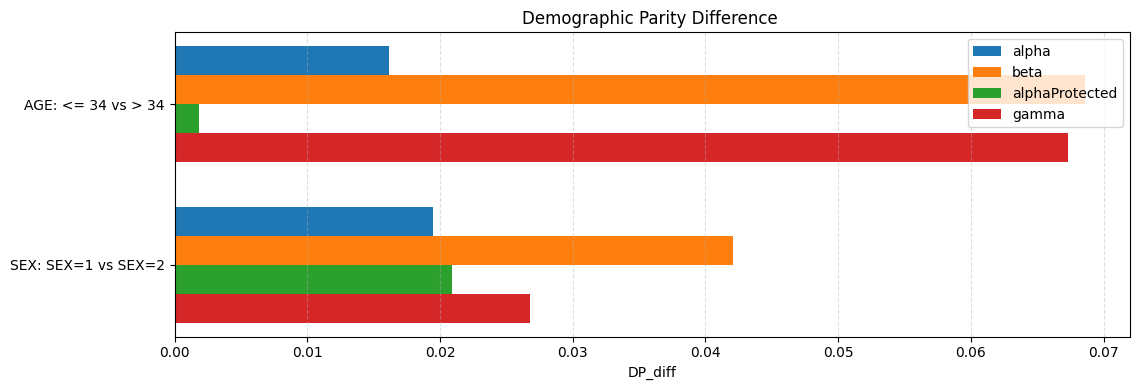

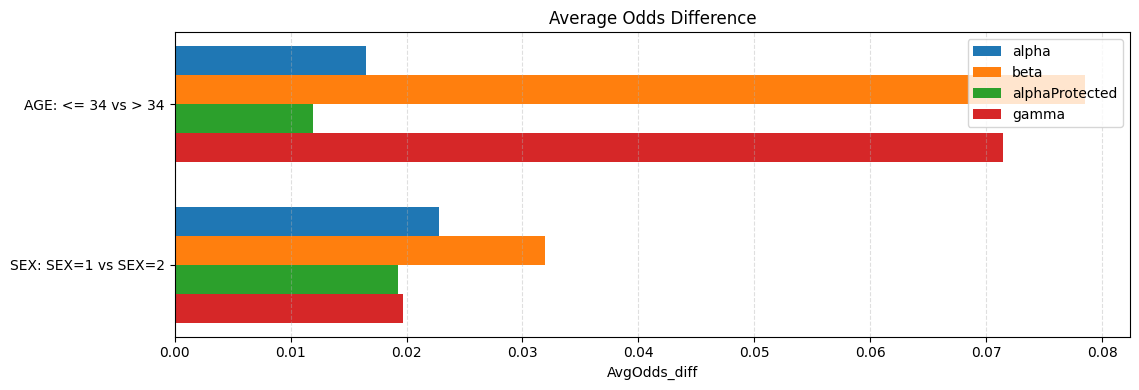

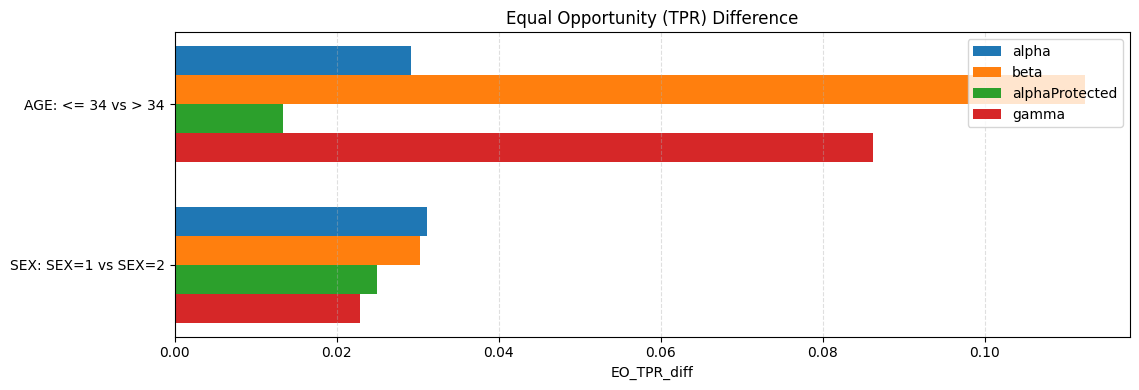

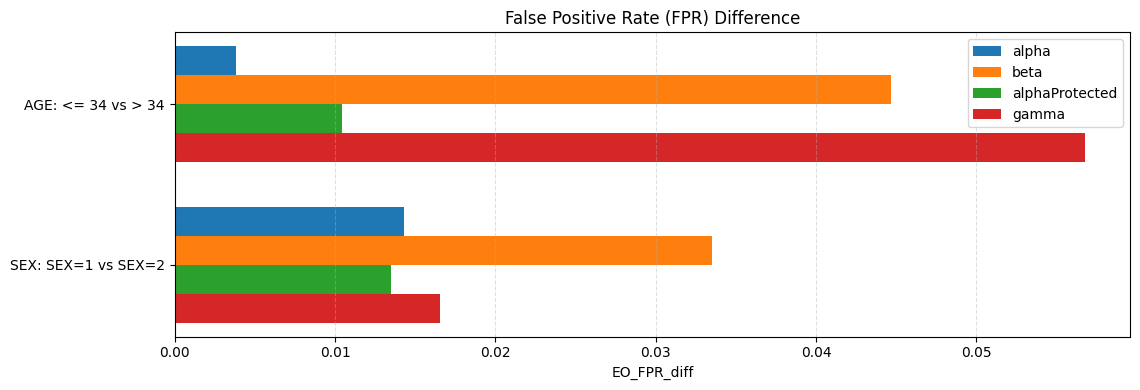

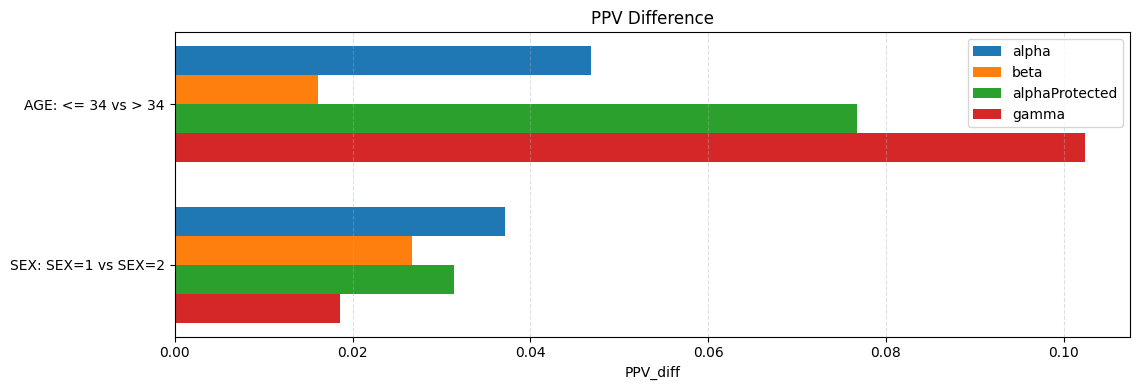

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

attr_order = ["sex", "race", "native-country", "age"]
model_order = ["alpha", "beta", "alphaProtected", "gamma"]

FAIR_ALL = FAIR_ALL.copy()
FAIR_ALL["attr_rank"] = FAIR_ALL["attr"].apply(lambda a: attr_order.index(a) if a in attr_order else 999)
FAIR_ALL["model_rank"] = FAIR_ALL["model"].apply(lambda m: model_order.index(m) if m in model_order else 999)
FAIR_ALL = FAIR_ALL.sort_values(["attr_rank", "attr_label", "model_rank"]).copy()

def plot_fair_metric(metric, title, xlabel):
    pivot = FAIR_ALL.pivot_table(index="attr_label", columns="model", values=metric, aggfunc="mean")
    pivot = pivot[[m for m in model_order if m in pivot.columns]]

    labels = pivot.index.tolist()
    y = np.arange(len(labels))
    h = 0.18

    plt.figure(figsize=(11.5, max(4.0, 0.6 * len(labels))))
    for i, m in enumerate(pivot.columns):
        vals = pivot[m].values
        plt.barh(y + (i - (len(pivot.columns)-1)/2)*h, vals, height=h, label=m)

    plt.yticks(y, labels)
    plt.gca().invert_yaxis()
    plt.xlabel(xlabel)
    plt.title(title)
    plt.grid(True, axis="x", linestyle="--", alpha=0.4)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

plot_fair_metric("DP_diff",      "Demographic Parity Difference ", "DP_diff")#Do both groups recieve positive predictions at the same rate?
plot_fair_metric("AvgOdds_diff", "Average Odds Difference",       "AvgOdds_diff")#Overall error parity across groups (Combines false negatives and false positives)
plot_fair_metric("EO_TPR_diff",  "Equal Opportunity (TPR) Difference", "EO_TPR_diff")#Are qualified positives treated equally (If someone truly belongs to the positive class, are they equally likely to be detected?)
plot_fair_metric("EO_FPR_diff",  "False Positive Rate (FPR) Difference", "EO_FPR_diff")#Are innocent individuals falsely flagged at equal rates?
plot_fair_metric("PPV_diff",     "PPV Difference", "PPV_diff")#When the model predicts positive, is it equally reliable?


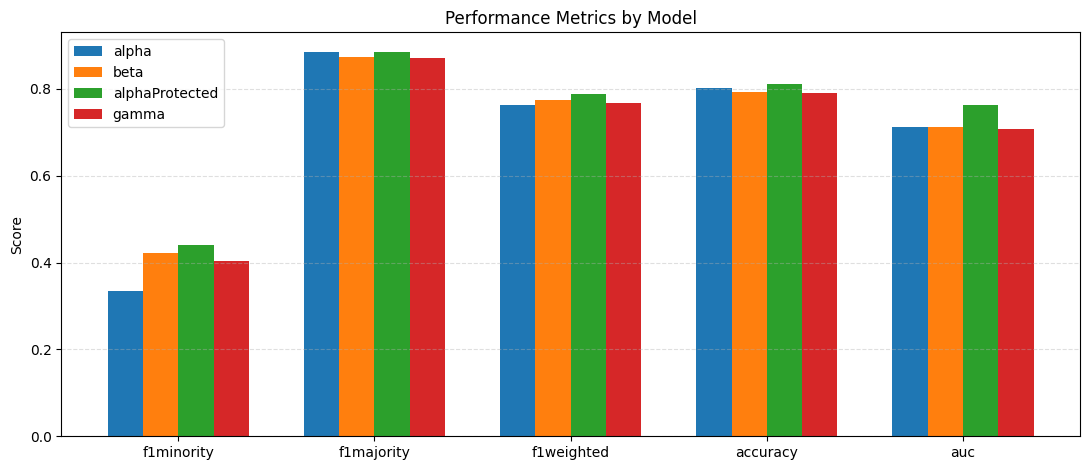

,model,f1minority,f1majority,f1weighted,accuracy,auc,model_rank
0,alpha,0.334414,0.883964,0.762422,0.802750,0.712673,0
2,beta,0.422214,0.873151,0.773419,0.792417,0.711596,1
1,alphaProtected,0.441056,0.885708,0.787366,0.810250,0.762240,2
3,gamma,0.402678,0.871812,0.768055,0.789750,0.707636,3


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

metric_order = ["f1minority", "f1majority", "f1weighted", "accuracy", "auc"]
model_order = ["alpha", "beta", "alphaProtected", "gamma"]

PERF_ALL = PERF_ALL.copy()
PERF_ALL["model_rank"] = PERF_ALL["model"].apply(lambda m: model_order.index(m) if m in model_order else 999)
PERF_ALL = PERF_ALL.sort_values("model_rank")

PERF_LONG = PERF_ALL.melt(
    id_vars=["model"],
    value_vars=[m for m in metric_order if m in PERF_ALL.columns],
    var_name="metric",
    value_name="value",
)
pivot = PERF_LONG.pivot_table(index="metric", columns="model", values="value", aggfunc="mean")
pivot = pivot.reindex(metric_order)
pivot = pivot[[m for m in model_order if m in pivot.columns]]

x = np.arange(len(pivot.index))
w = 0.18

plt.figure(figsize=(11, 4.8))
for i, m in enumerate(pivot.columns):
    plt.bar(x + (i - (len(pivot.columns)-1)/2)*w, pivot[m].values, width=w, label=m)

plt.xticks(x, pivot.index)
plt.ylabel("Score")
plt.title("Performance Metrics by Model")
plt.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

display(PERF_ALL)
